# MODEL TRAINING

### IMPORTING THE LIBRARIES

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# modeling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor


In [7]:
df = pd.read_csv('data/stud_clean.csv')

In [9]:
df.shape


(1000, 11)

In [11]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'total_score', 'average', 'pass'],
      dtype='str')

In [12]:
x = df.drop(['math score'], axis = 1)
y = df['math score']

In [16]:
# creating column transformers with 3 types of transformers
num_features = x.select_dtypes(exclude = "object").columns
cat_features = x.select_dtypes(include = "object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessing = ColumnTransformer(
    [
        ("OneHotEncoding", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)


In [18]:
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoding', ...), ('StandardScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`

In [23]:
X = preprocessing.fit_transform(x)
X

array([[ 1.        ,  0.        ,  0.        , ...,  0.34357423,
         0.34357423,  0.17586311],
       [ 1.        ,  0.        ,  0.        , ...,  1.0219275 ,
         1.0219275 ,  0.17586311],
       [ 1.        ,  0.        ,  0.        , ...,  1.74706375,
         1.74706375,  0.17586311],
       ...,
       [ 1.        ,  0.        ,  0.        , ..., -0.19443008,
        -0.19443008,  0.17586311],
       [ 1.        ,  0.        ,  0.        , ...,  0.46053169,
         0.46053169,  0.17586311],
       [ 1.        ,  0.        ,  0.        , ...,  1.06871048,
         1.06871048,  0.17586311]], shape=(1000, 22))

In [25]:
X.shape

(1000, 22)

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 22), (200, 22))

In [40]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    
    return mae, rmse, r2_square

In [41]:
models = {
    "linear regression": LinearRegression(),
    "lasso": Lasso(),
    "ridge": Ridge(),
    "k-neighbors regressor": KNeighborsRegressor(),
    "decision tree": DecisionTreeRegressor(),
    "random forest regressor": RandomForestRegressor(),
    "adaboost regressor": AdaBoostRegressor(),
    "xgbregressor": XGBRegressor(),
    "catboosting regressor": CatBoostRegressor(verbose=False),
}

model_list = []
r2_list = []

# Iterate directly over model names and estimator instances
for model_name, model in models.items():
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate train and test datasets
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(
        y_train, y_train_pred
    )
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(
        y_test, y_test_pred
    )

    print(model_name)
    model_list.append(model_name)

    print("model performance for training set")
    print(f" Root Mean Squared Error : {model_train_rmse:.4f}")
    print(f" Mean Absolute Error: {model_train_mae:.4f}")
    print(f" R2 Score : {model_train_r2:.4f}")

    print("----------------------------")

    print("Model performance for Test set")
    print(f" Root Mean Squared Error : {model_test_rmse:.4f}")
    print(f" Mean Absolute Error : {model_test_mae:.4f}")  # Fixed variable name
    print(f" R2 Score : {model_test_r2:.4f}")

    r2_list.append(model_test_r2)

linear regression
model performance for training set
 Root Mean Squared Error : 0.0000
 Mean Absolute Error: 0.0000
 R2 Score : 1.0000
----------------------------
Model performance for Test set
 Root Mean Squared Error : 0.0000
 Mean Absolute Error : 0.0000
 R2 Score : 1.0000
lasso
model performance for training set
 Root Mean Squared Error : 4.7381
 Mean Absolute Error: 3.7439
 R2 Score : 0.9004
----------------------------
Model performance for Test set
 Root Mean Squared Error : 4.7171
 Mean Absolute Error : 3.7579
 R2 Score : 0.9086
ridge
model performance for training set
 Root Mean Squared Error : 0.3396
 Mean Absolute Error: 0.2725
 R2 Score : 0.9995
----------------------------
Model performance for Test set
 Root Mean Squared Error : 0.3434
 Mean Absolute Error : 0.2686
 R2 Score : 0.9995
k-neighbors regressor
model performance for training set
 Root Mean Squared Error : 4.2685
 Mean Absolute Error: 3.3870
 R2 Score : 0.9192
----------------------------
Model performance for 

In [42]:
pd.DataFrame(list(zip(model_list, r2_list)), columns = ['Model Name', 'R2_Score']).sort_values(by = ["R2_Score"], ascending = False)

,Model Name,R2_Score
0,linear regression,1.000000
2,ridge,0.999515
7,xgbregressor,0.977101
8,catboosting regressor,0.969856
5,random forest regressor,0.963502
4,decision tree,0.941460
6,adaboost regressor,0.926535
1,lasso,0.908560
3,k-neighbors regressor,0.886720


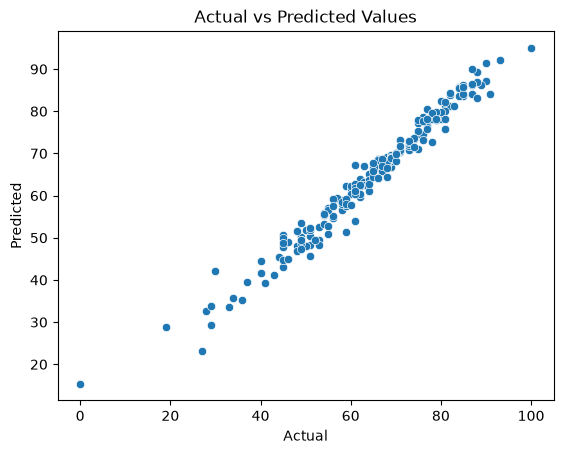

In [47]:
import seaborn as sns

sns.scatterplot(x=y_test, y=y_test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values")
plt.show()

In [52]:
import pandas as pd

pred_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_test_pred,
    'Difference': y_test - y_test_pred
})

pred_df.head()

,Actual Value,Predicted Value,Difference
521,91,83.997751,7.002249
737,53,52.569324,0.430676
740,80,78.955125,1.044875
660,74,73.668860,0.331140
411,84,85.659441,-1.659441
